In [86]:
# %pip install openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

df = pd.read_csv('../../Datasets/fromclass/ecommerce_sales_data.csv')
house = pd.read_csv('../../Datasets/fromclass/todays_house_with_zipcode.csv')
data = pd.read_excel('../../Datasets/fromclass/head_brain_synthetic_237rows.xlsx')

house.describe()

,YearSold,SqFt,Bedrooms,Bathrooms,GarageCars,LotSize,SalePrice,ZipCode
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2008.000000,2122.715000,3.100000,1.920000,1.010000,8421.035000,401791.485000,10002.410000
std,1.417762,762.476963,1.476789,0.822791,0.795654,3668.553706,116074.327832,1.121691
min,2006.000000,804.000000,1.000000,1.000000,0.000000,2077.000000,179648.000000,10001.000000
25%,2007.000000,1452.000000,2.000000,1.000000,0.000000,5333.000000,311355.500000,10001.000000
50%,2008.000000,2113.500000,3.000000,2.000000,1.000000,8097.000000,411346.500000,10002.000000
75%,2009.000000,2737.000000,4.250000,3.000000,2.000000,11779.250000,493864.000000,10003.000000
max,2010.000000,3460.000000,5.000000,3.000000,2.000000,14999.000000,611178.000000,10004.000000


array([20240.42810345])

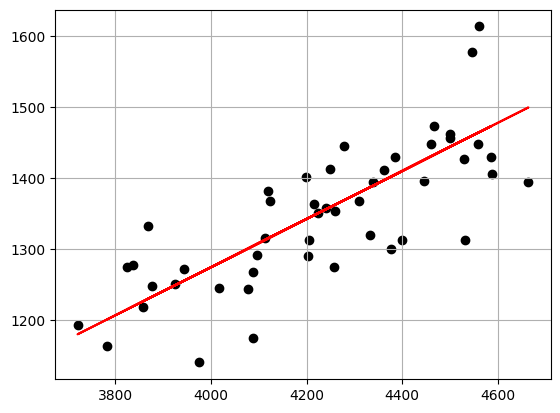

In [87]:

lr = LinearRegression()

def results_df(x_test,y_test, y_prep):
    df= pd.DataFrame({
    'SqFt': x_test['SqFt'].values,
    'Bedrooms': x_test['Bedrooms'].values,
    'Bathrooms': x_test['Bathrooms'].values,
    'GarageCars': x_test['GarageCars'].values,
    'Actual Price (y)': y_test.values,
    'Predicted Price (ŷ)': y_prep.round(2),
    'Residual (y - ŷ)': y_test.values - y_prep
})
    return df

def predic(SqFt, Bedrooms, Bathrooms,GarageCars, zip):

  return lr.predict([[SqFt, Bedrooms, Bathrooms,GarageCars, zip]])[0]

data.head(10)

X = data['Head Size(cm^3)'].values
Y = data['Brain Weight(grams)'].values
X = X.reshape(-1,1)
df, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.20)

lr = LinearRegression()
lr.fit(df, Y_train)

Y_pred = lr.predict(X_test)
r2 = r2_score(Y_test,Y_pred)
r2
plt.scatter(X_test, Y_test, color='black', label='Actual')
plt.plot(X_test, Y_pred, color='red', label='Test')
plt.grid()
lr.predict([[60000]])

In [88]:
X = house[['SqFt', 'Bedrooms', 'Bathrooms','GarageCars', 'ZipCode']]
Y = house['SalePrice']


x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)
lr.fit(x_train, y_train)

y_prep = lr.predict(x_test)
r2 = r2_score(y_test, y_prep)


# plt.scatter(y_test, y_prep, color='skyblue')
# plt.xlabel("Actual Price")
# plt.ylabel("Predicted Price")
# plt.grid()
# plt.show()

# lr.predict(2730, 1, 1, 0, 10004)

r2


0.9630395546298243

In [89]:
house[['SqFt','Bedrooms', 'Bathrooms', 'GarageCars', 'SalePrice']]
house['SalePrice'].min()

np.int64(179648)

In [90]:
# week_data = [1,2,3,4,5]
# sales_data = [2,4,5,4,5]
# df = pd.DataFrame({'Weeks': week_data,
#                    'Sales': sales_data})
# df
# X = df['Weeks'].values
# Y = df['Sales'].values
# mean_x = np.mean(X)
# mean_y = np.mean(Y)
# n = len(X)
# numer = 0
# denom = 0
# for i in range(n):
#   numer += (X[i] - mean_x) * (Y[i] - mean_y)
#   denom += (X[i] - mean_x) **2
# m = numer / denom
# m 
# c = mean_y -(m * mean_x)
# c
# max_x = np.max(X)+2
# min_x = np.min(X) -2
# x = np.linspace(min_x, max_x)
# y = c + (m * x)
# # plt.plot(x,y, color='#ff477c', label='Regression Line', linestyle='--', linewidth=4)
# # plt.scatter(X,Y, color='#29c200', label='Data', s=100)
# # plt.legend(loc='best')
# ss_tot =0
# ss_res = 0
# for i in range(n):
#   y_pred = c + (m * X[i]) 
#   ss_tot += (Y[i] - mean_y)**2
#   ss_res += (Y[i] - y_pred)**2
# X = X.reshape(-1,1)
# lr = LinearRegression()
# xt, xts, yt, yts, =train_test_split(X, Y, test_size=0.20, random_state=42)
# lr.fit(xt,yt)
# yp = lr.predict(xts)
# r3 = r2_score(yts, yp)
# r3


In [91]:


# 1. Create the data directly (No file needed)
data = {
    'Id': [1, 2, 3, 4, 5],
    'Neighborhood': ['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'CollgCr'],
    'HouseStyle': ['2Story', '1Story', '2Story', '2Story', '1Story'],
}
df = pd.DataFrame(data)

df = pd.get_dummies(df.drop('Id', axis=1), dtype=bool)


bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# d	Neighborhood	HouseStyle	CentralAir	NewlyRenovated
# 0	1	CollgCr	2Story	Y	True
# 1	2	Veenker	1Story	N	False
# 2	3	Crawfor	2Story	Y	True
# 3	4	NoRidge	2Story	Y	False
# 4	5	CollgCr	1Story	N	False



df

,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_NoRidge,Neighborhood_Veenker,HouseStyle_1Story,HouseStyle_2Story
0,1,0,0,0,0,1
1,0,0,0,1,1,0
2,0,1,0,0,0,1
3,0,0,1,0,0,1
4,1,0,0,0,1,0
